In [81]:
import numpy as np
from scipy.stats import norm

def black_scholes(S, K, sigma, r, t):
    d1 = (np.log(S/K) + (r + ((sigma ** 2) / 2) * t)) / (sigma * np.sqrt(t))
    d2 = d1 - (sigma * np.sqrt(t))
    C = S * norm.cdf(d1) - K * np.exp(-r * t) * norm.cdf(d2)
    return C

S = 100 # Spot price
K = 100 # Strike price
sigma = 0.76 # Volatility of asset
r = 0.05 # Risk-free return
t = 1 # Time to maturity (years)
dt = t / 252 # Time step

bs = black_scholes(S, K, sigma, r, t)

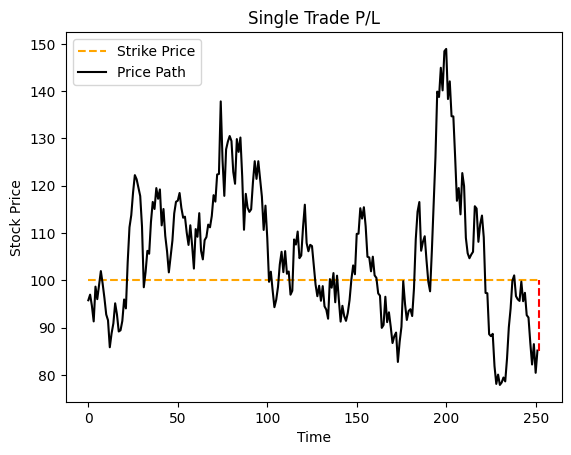

Premium as t=0: 31.381569109336127
P/L: -31.381569109336127


In [82]:
import qfin as qf
import matplotlib.pyplot as plt

path = qf.simulations.GeometricBrownianMotion(S, r, sigma, dt, t)
itm = max(path.simulated_path[-1] - K, 0)

plt.title("Single Trade P/L")
plt.hlines(100, 0, 252, label='Strike Price', color='orange', linestyles='dashed')
plt.plot(path.simulated_path, label='Price Path', color='black')
if itm == 0:
    plt.vlines(252, path.simulated_path[-1], K, color='red', linestyles='dashed')
else:
    plt.vlines(252, K, path.simulated_path[-1], color='green', linestyles='dashed')
plt.ylabel('Stock Price')
plt.xlabel('Time')
plt.legend()
plt.show()

print("Premium as t=0:", bs)
print("P/L:", itm - bs)

In [83]:
ask = 14.13

premium = 100 * ask
pls = []
iterations = 100000

for i in range(iterations):
    path = qf.simulations.GeometricBrownianMotion(S, r, sigma, dt, t)
    pls.append(max(path.simulated_path[-1] - K, 0) * 100 - premium)

# expected value
print("E(x):", np.mean(pls))

E(x): 1845.028619792466


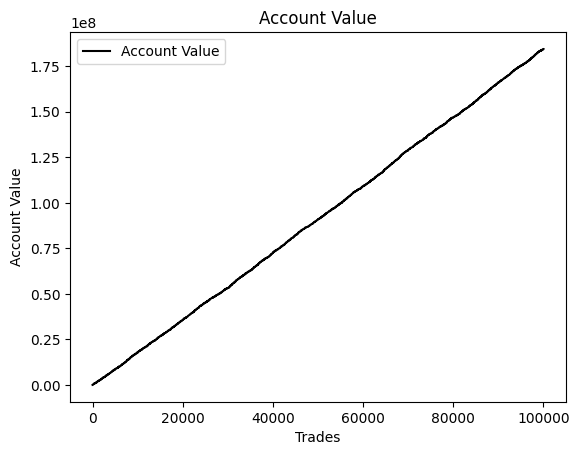

In [84]:
val = []

for i in range(iterations):
    if i == 0:
        val.append(pls[i])
    else:
        val.append(val[i - 1] + pls[i])

plt.title("Account Value")
plt.plot(val, label='Account Value', color='black')
plt.ylabel('Account Value')
plt.xlabel('Trades')
plt.legend()
plt.show()


In [91]:
print(black_scholes(58.79, 58, 0.7716, 0.451, 235/365))

21.209073962047263
